# Solution: Handling Missing Data -- Planets Dataset

**Exercises from notebook `01_handling_missing_data.ipynb`**

Jingxu Li - 320230942071


## Exercise 1: Profile Missing Values

Load the seaborn planets dataset and profile its missing values. Which columns are affected and by how much?


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/planets.csv')
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
profile = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct.round(2)})
profile = profile[profile['Missing Count'] > 0].sort_values('Percentage (%)', ascending=False)
print("Missing value profile:")
profile


Missing value profile:


,Missing Count,Percentage (%)
mass,522,50.43
distance,227,21.93
orbital_period,43,4.15


## Exercise 2: MCAR / MAR Diagnosis

Check whether missingness in orbital_period is MCAR or MAR by comparing mean mass between rows with and without orbital_period.


In [16]:
df['orbital_period_missing'] = df['orbital_period'].isnull().astype(int)
mass_means = df.groupby('orbital_period_missing')['mass'].mean()
dist_means = df.groupby('orbital_period_missing')['distance'].mean()
print("Mean mass by orbital_period_missing:")
print(mass_means)
print("\nMean distance by orbital_period_missing:")
print(dist_means)


print("\nConclusion: distance differs significantly between groups,")
print("so missingness in orbital_period depends on distance -> MAR (not MCAR).")


Mean mass by orbital_period_missing:
orbital_period_missing
0    2.638161
1         NaN
Name: mass, dtype: float64

Mean distance by orbital_period_missing:
orbital_period_missing
0     219.116985
1    1354.162500
Name: distance, dtype: float64

Conclusion: distance differs significantly between groups,
so missingness in orbital_period depends on distance -> MAR (not MCAR).


## Exercise 3: MICE Imputation

Apply MICE imputation to the numeric columns and plot the orbital_period distribution before and after.


Numeric columns for imputation: ['number', 'orbital_period', 'mass', 'distance', 'year']


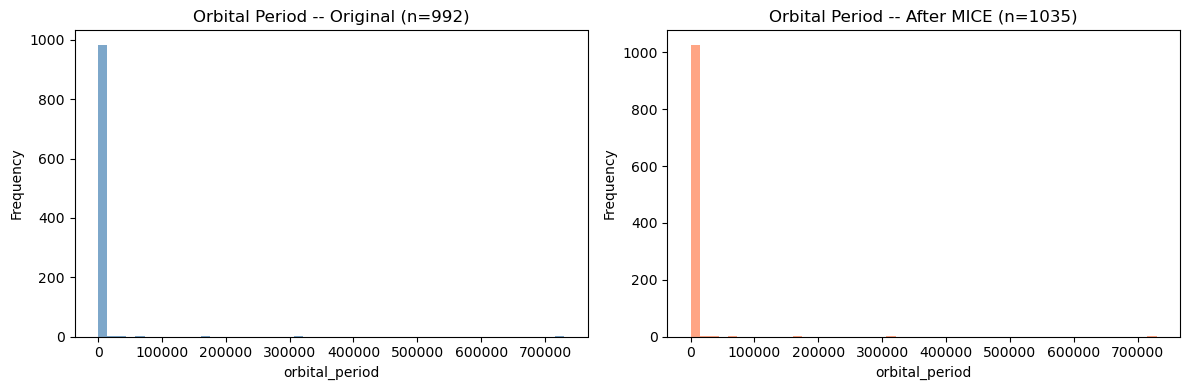

In [17]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'orbital_period_missing' in num_cols:
    num_cols.remove('orbital_period_missing')
print("Numeric columns for imputation:", num_cols)

mice = IterativeImputer(max_iter=10, random_state=42)
df_imputed = mice.fit_transform(df[num_cols])
df_imputed = pd.DataFrame(df_imputed, columns=num_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['orbital_period'].dropna(), bins=50, color='steelblue', alpha=0.7)
axes[0].set_title(f'Orbital Period -- Original (n={df["orbital_period"].notna().sum()})')
axes[0].set_xlabel('orbital_period')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_imputed['orbital_period'], bins=50, color='coral', alpha=0.7)
axes[1].set_title(f'Orbital Period -- After MICE (n={len(df_imputed)})')
axes[1].set_xlabel('orbital_period')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


## Exercise 4: Regression Pipeline -- MICE vs Mean Imputation

Build a regression pipeline to predict orbital_period from other features -- compare MICE vs mean imputation in cross-validation.


Mean Imputation -- R2: -3.3594 (+/- 12.6721)
MICE Imputation -- R2: -16.0051 (+/- 63.7215)


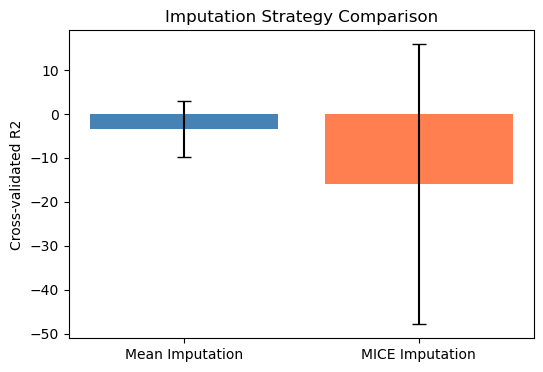

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score

feature_cols = [c for c in num_cols if c != 'orbital_period']
df_clean = df.dropna(subset=['orbital_period']).copy()
X = df_clean[feature_cols]
y = df_clean['orbital_period']

mean_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

mice_pipe = Pipeline([
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

mean_scores = cross_val_score(mean_pipe, X, y, cv=5, scoring='r2')
mice_scores = cross_val_score(mice_pipe, X, y, cv=5, scoring='r2')

print(f"Mean Imputation -- R2: {mean_scores.mean():.4f} (+/- {mean_scores.std() * 2:.4f})")
print(f"MICE Imputation -- R2: {mice_scores.mean():.4f} (+/- {mice_scores.std() * 2:.4f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Mean Imputation', 'MICE Imputation'],
       [mean_scores.mean(), mice_scores.mean()],
       yerr=[mean_scores.std(), mice_scores.std()],
       capsize=5, color=['steelblue', 'coral'])
ax.set_ylabel('Cross-validated R2')
ax.set_title('Imputation Strategy Comparison')
plt.show()
